# Experiment: Predicting Observed Helpfulness in Amazon Movies & TV Reviews

This notebook finishes the NLP final-project experiments for predicting whether an Amazon Movies & TV review receives observed helpful votes. The main experiment uses the full 50,000-review representative subset and treats `helpful_vote >= 1` as the positive class. Because zero helpful votes may mean low exposure rather than true unhelpfulness, the results are interpreted as prediction of *observed helpfulness*, not perfect human helpfulness.


## Notebook Roadmap

1. Load the saved representative 50K subset and keep the earlier full-corpus reference statistics.
2. Explore the imbalance, timestamp/exposure patterns, text length, rating, verified-purchase status, and simple plot/emotion indicators.
3. Train several NLP classifiers on the full 50K subset using stratified train/validation/test splits.
4. Select the best model by validation PR-AUC, tune its decision threshold on validation, and report final held-out test results.
5. Run two secondary analyses: an exposed-only comparison and a mature-window robustness check.
6. Generate final Method and Results notes for the report from the actual notebook outputs.


## 1. Setup

This cell imports the libraries, fixes random seeds, configures display settings, and records the main experiment constants. The notebook uses only standard Python data tools and scikit-learn models so it stays practical for a course project.


In [1]:
from __future__ import annotations

import json
import os
import re
import warnings
from collections import Counter
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str((Path.cwd() / "output" / "jupyter-notebook" / "tmp" / "matplotlib").resolve())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import sparse
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
SAMPLE_SIZE = 50_000
TEST_SIZE = 0.15
VAL_SIZE_OF_TRAINVAL = 0.15 / 0.85
POSITIVE_VOTE_THRESHOLD = 1
EXPOSED_STRONG_THRESHOLD = 2
MATURE_YEAR_CUTOFF = 2014
TFIDF_MAX_FEATURES = 20_000

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Locate Data and Helper Functions

The subset was already created by reservoir sampling from the full Movies & TV corpus in the baseline notebook. The helper functions below load that subset, normalize title/body text, count simple text features, and format values for readable tables.


In [2]:
def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "dataset" / "23_Movies_and_TV_subset_50000.jsonl").exists():
            return candidate
    raise FileNotFoundError("Could not locate dataset/23_Movies_and_TV_subset_50000.jsonl.")


PROJECT_ROOT = find_project_root()
SUBSET_PATH = PROJECT_ROOT / "dataset" / "23_Movies_and_TV_subset_50000.jsonl"
REPORT_SUMMARY_PATH = PROJECT_ROOT / "output" / "jupyter-notebook" / "helpfulness_final_results_summary.json"

FULL_CORPUS_REFERENCE = {
    "source_name": "Amazon Reviews 2023 - Movies_and_TV",
    "source_url": "https://amazon-reviews-2023.github.io/",
    "documents": 17_328_314,
    "words": 800_222_436,
    "sentences": 75_691_271,
    "mean_words_per_review": 46.1801,
    "mean_sentences_per_review": 4.3681,
    "zero_vote_share": 0.7504,
    "exposed_share": 0.2496,
    "verified_share": 0.7939,
    "rating_shares": {1.0: 0.0814, 2.0: 0.0442, 3.0: 0.0727, 4.0: 0.1503, 5.0: 0.6513},
    "vote_bin_shares": {"0": 0.7504, "1": 0.1208, "2": 0.0438, "3-4": 0.0368, "5+": 0.0482},
}

SENTENCE_RE = re.compile(r"[.!?]+")
TOKEN_RE = re.compile(r"[a-z']+")


def normalize_text(title: str | None, text: str | None) -> str:
    title = (title or "").strip()
    text = (text or "").strip()
    return " ".join(part for part in [title, text] if part)


def count_words(text: str) -> int:
    return len(text.split()) if text else 0


def count_sentences(text: str) -> int:
    if not text:
        return 0
    matches = SENTENCE_RE.findall(text)
    return len(matches) if matches else 1


def helpful_vote_bin(value: int) -> str:
    if value <= 2:
        return str(value)
    if value <= 4:
        return "3-4"
    return "5+"


def format_int(value: int | float) -> str:
    return f"{int(value):,}"


def format_pct(value: float) -> str:
    return f"{value * 100:.2f}%"


def safe_rate(numerator: float, denominator: float) -> float:
    return numerator / denominator if denominator else np.nan


## 3. Load and Prepare the 50K Subset

This cell loads every review in the representative subset, creates the main `any_helpful` label, converts timestamps to years, and adds interpretable text/style features. These features support both EDA and the feature-enhanced classifier later in the notebook.


In [3]:
with SUBSET_PATH.open("r", encoding="utf-8") as handle:
    subset_records = [json.loads(line) for line in handle]

subset_df = pd.DataFrame(subset_records)
subset_df["title"] = subset_df["title"].fillna("")
subset_df["text"] = subset_df["text"].fillna("")
subset_df["review_text"] = subset_df.apply(lambda row: normalize_text(row["title"], row["text"]), axis=1)
subset_df["helpful_vote"] = subset_df["helpful_vote"].fillna(0).astype(int)
subset_df["rating"] = subset_df["rating"].astype(float)
subset_df["verified_purchase"] = subset_df["verified_purchase"].fillna(False).astype(bool)
subset_df["review_datetime"] = pd.to_datetime(subset_df["timestamp"], unit="ms", errors="coerce")
subset_df["review_year"] = subset_df["review_datetime"].dt.year
subset_df["review_word_count"] = subset_df["review_text"].map(count_words)
subset_df["title_word_count"] = subset_df["title"].map(count_words)
subset_df["sentence_count"] = subset_df["review_text"].map(count_sentences)
subset_df["exclamation_count"] = subset_df["review_text"].str.count("!")
subset_df["question_count"] = subset_df["review_text"].str.count(r"\?")
subset_df["log_review_word_count"] = np.log1p(subset_df["review_word_count"])
subset_df["verified_purchase_int"] = subset_df["verified_purchase"].astype(int)
subset_df["any_helpful"] = (subset_df["helpful_vote"] >= POSITIVE_VOTE_THRESHOLD).astype(int)
subset_df["vote_bin"] = subset_df["helpful_vote"].map(helpful_vote_bin)

PLOT_WORDS = {
    "plot", "story", "character", "characters", "acting", "actor", "actors", "actress", "scene",
    "scenes", "episode", "episodes", "script", "performance", "director", "ending", "dialogue",
    "cast", "sequel", "cinematography", "soundtrack", "writing"
}
EMOTION_WORDS = {
    "love", "loved", "hate", "hated", "funny", "sad", "cry", "crying", "emotional", "boring",
    "scary", "exciting", "disappointed", "happy", "awful", "amazing", "terrible", "hilarious",
    "angry", "beautiful", "favorite", "worst", "best"
}


def count_lexicon_terms(text: str, lexicon: set[str]) -> int:
    tokens = TOKEN_RE.findall(text.lower())
    return sum(token in lexicon for token in tokens)


subset_df["plot_term_count"] = subset_df["review_text"].map(lambda text: count_lexicon_terms(text, PLOT_WORDS))
subset_df["emotion_term_count"] = subset_df["review_text"].map(lambda text: count_lexicon_terms(text, EMOTION_WORDS))
subset_df["has_plot_terms"] = subset_df["plot_term_count"] > 0
subset_df["has_emotion_terms"] = subset_df["emotion_term_count"] > 0

style_conditions = [
    subset_df["has_plot_terms"] & subset_df["has_emotion_terms"],
    subset_df["has_plot_terms"] & ~subset_df["has_emotion_terms"],
    ~subset_df["has_plot_terms"] & subset_df["has_emotion_terms"],
]
style_choices = ["Both plot and emotion", "Plot-focused", "Emotion-focused"]
subset_df["style_group"] = np.select(style_conditions, style_choices, default="Neither")
subset_df["length_quartile"] = pd.qcut(
    subset_df["review_word_count"].rank(method="first"),
    q=4,
    labels=["Very short", "Short", "Medium", "Long"],
)

modeling_df = subset_df.loc[subset_df["review_text"].str.len() > 0].copy()

print(f"Loaded subset rows: {format_int(len(subset_df))}")
print(f"Rows with non-empty title/body text: {format_int(len(modeling_df))}")
print(f"Review years: {int(subset_df['review_year'].min())}-{int(subset_df['review_year'].max())}")
print(f"Observed helpful-vote positive rate: {format_pct(modeling_df['any_helpful'].mean())}")


Loaded subset rows: 50,000
Rows with non-empty title/body text: 50,000
Review years: 1998-2023
Observed helpful-vote positive rate: 25.31%


## 4. Dataset Summary and Subset Validation

The table below keeps the original full-corpus context while making the 50K subset the unit of analysis for the final experiments. The subset preserves the main imbalance: roughly three quarters of reviews have zero observed helpful votes.


In [4]:
subset_summary = {
    "documents": len(subset_df),
    "words": int(subset_df["review_word_count"].sum()),
    "sentences": int(subset_df["sentence_count"].sum()),
    "mean_words_per_review": subset_df["review_word_count"].mean(),
    "mean_sentences_per_review": subset_df["sentence_count"].mean(),
    "zero_vote_share": (subset_df["helpful_vote"] == 0).mean(),
    "exposed_share": (subset_df["helpful_vote"] >= 1).mean(),
    "verified_share": subset_df["verified_purchase"].mean(),
}

summary_table = pd.DataFrame(
    [
        {
            "Dataset": "Full corpus reference",
            "Documents": FULL_CORPUS_REFERENCE["documents"],
            "Words": FULL_CORPUS_REFERENCE["words"],
            "Sentences": FULL_CORPUS_REFERENCE["sentences"],
            "Mean words/review": FULL_CORPUS_REFERENCE["mean_words_per_review"],
            "Mean sentences/review": FULL_CORPUS_REFERENCE["mean_sentences_per_review"],
            "Zero-vote share": FULL_CORPUS_REFERENCE["zero_vote_share"],
            "Exposed share": FULL_CORPUS_REFERENCE["exposed_share"],
            "Verified-purchase share": FULL_CORPUS_REFERENCE["verified_share"],
        },
        {
            "Dataset": "Representative subset",
            "Documents": subset_summary["documents"],
            "Words": subset_summary["words"],
            "Sentences": subset_summary["sentences"],
            "Mean words/review": subset_summary["mean_words_per_review"],
            "Mean sentences/review": subset_summary["mean_sentences_per_review"],
            "Zero-vote share": subset_summary["zero_vote_share"],
            "Exposed share": subset_summary["exposed_share"],
            "Verified-purchase share": subset_summary["verified_share"],
        },
    ]
)

subset_rating_shares = subset_df["rating"].value_counts(normalize=True).sort_index()
subset_vote_bin_shares = subset_df["vote_bin"].value_counts(normalize=True).reindex(["0", "1", "2", "3-4", "5+"])

rating_distribution = pd.DataFrame(
    {
        "Category": [1.0, 2.0, 3.0, 4.0, 5.0],
        "Full reference share": [FULL_CORPUS_REFERENCE["rating_shares"][r] for r in [1.0, 2.0, 3.0, 4.0, 5.0]],
        "Subset share": [subset_rating_shares.get(r, 0.0) for r in [1.0, 2.0, 3.0, 4.0, 5.0]],
    }
)
rating_distribution["Abs diff (pp)"] = (
    rating_distribution["Full reference share"] - rating_distribution["Subset share"]
).abs() * 100

vote_distribution = pd.DataFrame(
    {
        "Category": ["0", "1", "2", "3-4", "5+"],
        "Full reference share": [FULL_CORPUS_REFERENCE["vote_bin_shares"][b] for b in ["0", "1", "2", "3-4", "5+"]],
        "Subset share": [subset_vote_bin_shares.get(b, 0.0) for b in ["0", "1", "2", "3-4", "5+"]],
    }
)
vote_distribution["Abs diff (pp)"] = (
    vote_distribution["Full reference share"] - vote_distribution["Subset share"]
).abs() * 100

display(summary_table)
display(rating_distribution)
display(vote_distribution)


,Dataset,Documents,Words,Sentences,Mean words/review,Mean sentences/review,Zero-vote share,Exposed share,Verified-purchase share
0,Full corpus reference,17328314,800222436,75691271,46.1801,4.3681,0.7504,0.2496,0.7939
1,Representative subset,50000,2325825,182699,46.5165,3.6540,0.7469,0.2531,0.7939


,Category,Full reference share,Subset share,Abs diff (pp)
0,1.0000,0.0814,0.0811,0.0300
1,2.0000,0.0442,0.0449,0.0720
2,3.0000,0.0727,0.0725,0.0240
3,4.0000,0.1503,0.1502,0.0080
4,5.0000,0.6513,0.6513,0.0000


,Category,Full reference share,Subset share,Abs diff (pp)
0,0,0.7504,0.7469,0.3480
1,1,0.1208,0.1220,0.1180
2,2,0.0438,0.0437,0.0080
3,3-4,0.0368,0.0390,0.2240
4,5+,0.0482,0.0483,0.0140


## 5. Helpful-Vote Imbalance

The main modeling challenge is visible here: most reviews have zero observed helpful votes, while a small minority have one or more. This motivates using PR-AUC, recall, F1, and balanced accuracy rather than relying only on raw accuracy.


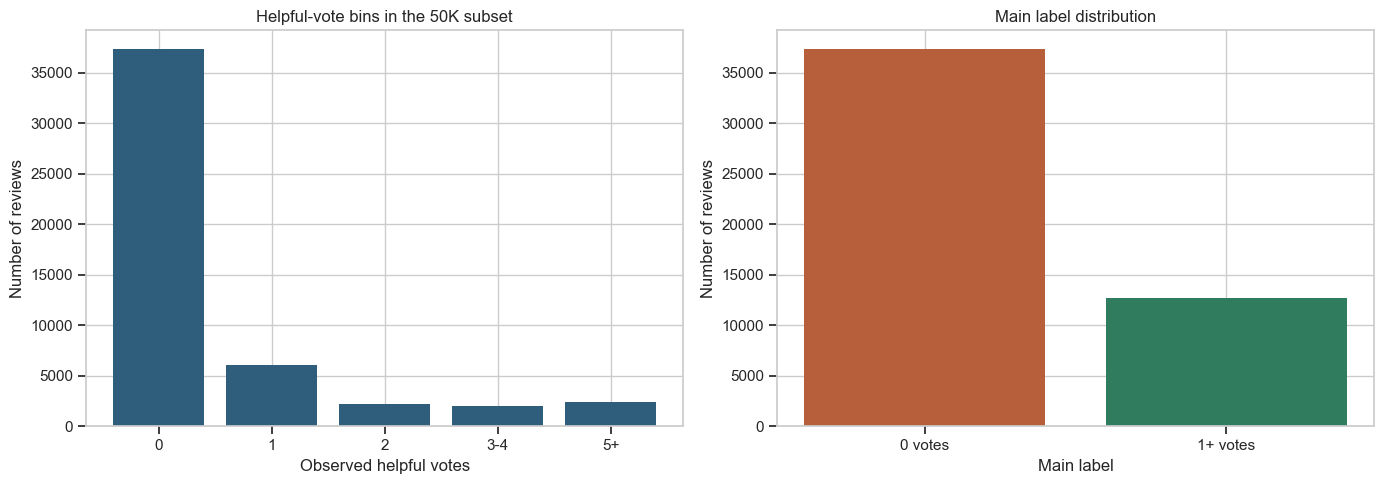

,Class,Count,Share
0,0 observed helpful votes,37346,0.7469
1,1+ observed helpful votes,12654,0.2531


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vote_counts = subset_df["vote_bin"].value_counts().reindex(["0", "1", "2", "3-4", "5+"])
axes[0].bar(vote_counts.index, vote_counts.values, color="#2f5d7c")
axes[0].set_title("Helpful-vote bins in the 50K subset")
axes[0].set_xlabel("Observed helpful votes")
axes[0].set_ylabel("Number of reviews")

class_counts = modeling_df["any_helpful"].value_counts().sort_index()
axes[1].bar(["0 votes", "1+ votes"], class_counts.values, color=["#b65f3a", "#2f7c5f"])
axes[1].set_title("Main label distribution")
axes[1].set_xlabel("Main label")
axes[1].set_ylabel("Number of reviews")

plt.tight_layout()
plt.show()

label_summary = pd.DataFrame(
    {
        "Class": ["0 observed helpful votes", "1+ observed helpful votes"],
        "Count": [int(class_counts.get(0, 0)), int(class_counts.get(1, 0))],
        "Share": [class_counts.get(0, 0) / class_counts.sum(), class_counts.get(1, 0) / class_counts.sum()],
    }
)
display(label_summary)


## 6. Exposure Proxy: Review Year

Older reviews have had more time to be seen and voted on. The year trend below supports the decision to include a mature-window robustness analysis later instead of treating all zero-vote reviews as certainly unhelpful.


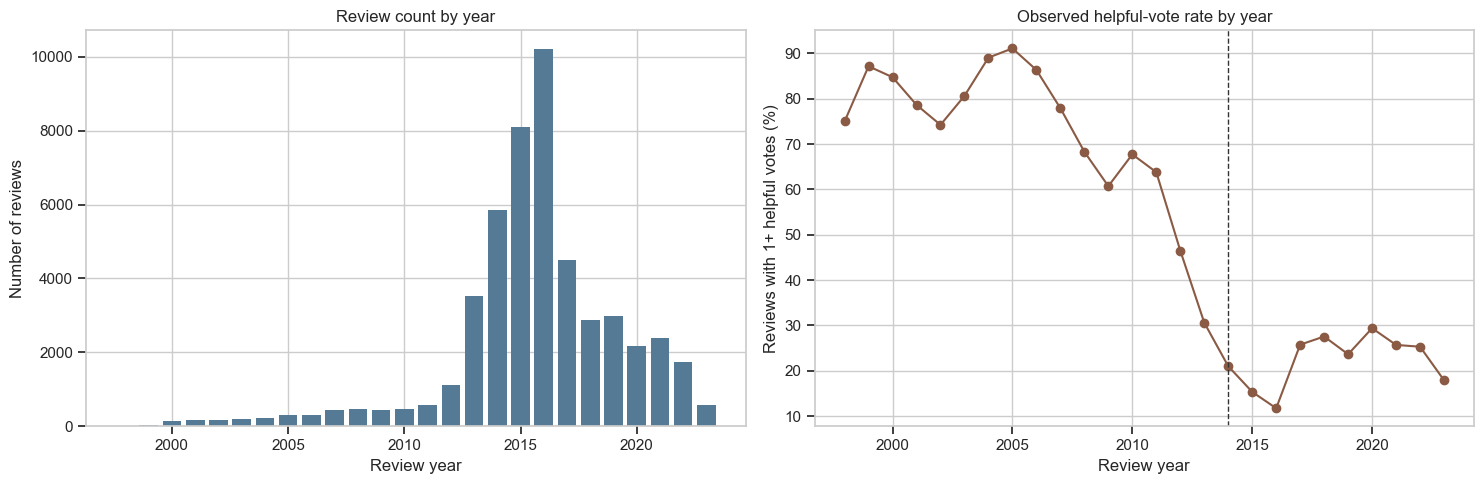

,review_year,reviews,observed_helpful_rate,mean_helpful_votes
14,2012,1107,0.4652,2.0650
15,2013,3520,0.3063,1.0009
16,2014,5848,0.2102,0.8613
17,2015,8113,0.1535,0.5304
18,2016,10206,0.1174,0.3199
19,2017,4498,0.2577,0.8584
20,2018,2884,0.2757,1.1702
21,2019,2973,0.2365,1.3273
22,2020,2184,0.2940,1.2976
23,2021,2392,0.2571,1.2291


In [6]:
year_summary = (
    subset_df.groupby("review_year")
    .agg(
        reviews=("helpful_vote", "size"),
        observed_helpful_rate=("any_helpful", "mean"),
        mean_helpful_votes=("helpful_vote", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(year_summary["review_year"], year_summary["reviews"], color="#557a95")
axes[0].set_title("Review count by year")
axes[0].set_xlabel("Review year")
axes[0].set_ylabel("Number of reviews")

axes[1].plot(year_summary["review_year"], year_summary["observed_helpful_rate"] * 100, marker="o", color="#8a5a44")
axes[1].axvline(MATURE_YEAR_CUTOFF, color="#333333", linestyle="--", linewidth=1)
axes[1].set_title("Observed helpful-vote rate by year")
axes[1].set_xlabel("Review year")
axes[1].set_ylabel("Reviews with 1+ helpful votes (%)")

plt.tight_layout()
plt.show()

display(year_summary.tail(12))


## 7. Feature-Oriented EDA

These tables connect the research questions to measurable features: length, rating, verified-purchase status, and simple lexical markers for plot-focused or emotion-focused review language.


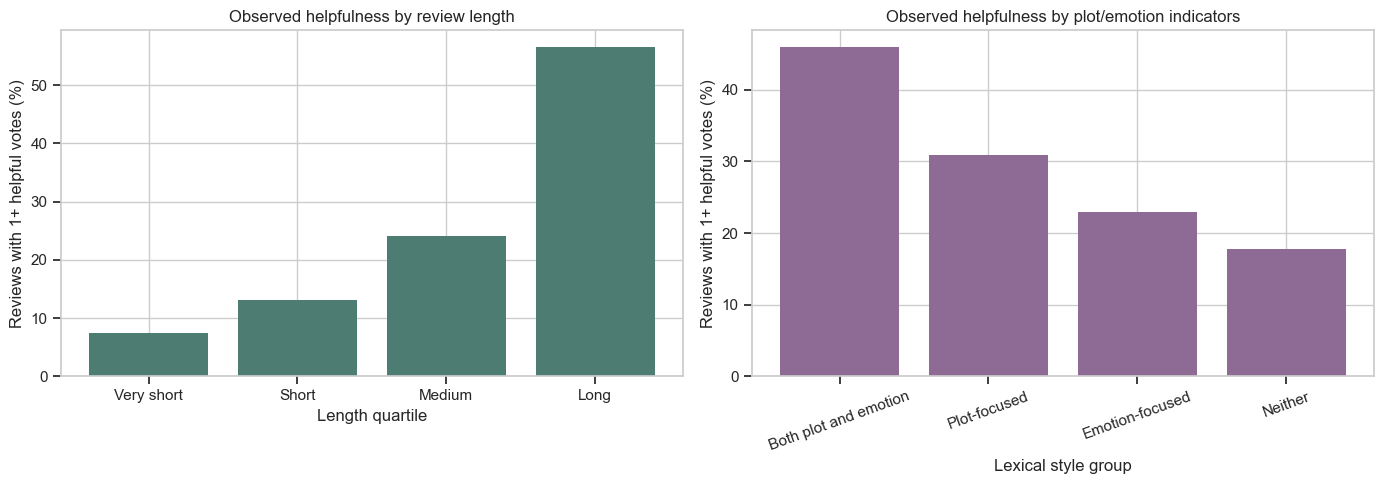

,length_quartile,reviews,median_words,observed_helpful_rate,mean_helpful_votes
0,Very short,12500,5.0000,0.0749,0.1022
1,Short,12500,13.0000,0.1310,0.2709
2,Medium,12500,30.0000,0.2406,0.5907
3,Long,12500,85.0000,0.5659,3.5930


,rating,reviews,observed_helpful_rate,mean_helpful_votes
0,1.0000,4055,0.5127,2.6387
1,2.0000,2246,0.3753,1.9550
2,3.0000,3623,0.3031,1.4013
3,4.0000,7511,0.2343,0.9615
4,5.0000,32565,0.2111,0.9080


,verified_purchase,reviews,observed_helpful_rate,mean_helpful_votes
0,Not verified,10306,0.4098,2.5319
1,Verified,39694,0.2124,0.7776


,style_group,reviews,observed_helpful_rate,mean_helpful_votes,median_words
0,Both plot and emotion,7720,0.4600,3.1933,66.0000
1,Plot-focused,7251,0.3091,1.3449,35.0000
2,Emotion-focused,12652,0.2289,0.8516,20.0000
3,Neither,22377,0.1772,0.5264,11.0000


In [7]:
length_summary = (
    subset_df.groupby("length_quartile", observed=True)
    .agg(
        reviews=("any_helpful", "size"),
        median_words=("review_word_count", "median"),
        observed_helpful_rate=("any_helpful", "mean"),
        mean_helpful_votes=("helpful_vote", "mean"),
    )
    .reset_index()
)

rating_summary = (
    subset_df.groupby("rating")
    .agg(
        reviews=("any_helpful", "size"),
        observed_helpful_rate=("any_helpful", "mean"),
        mean_helpful_votes=("helpful_vote", "mean"),
    )
    .reset_index()
)

verified_summary = (
    subset_df.groupby("verified_purchase")
    .agg(
        reviews=("any_helpful", "size"),
        observed_helpful_rate=("any_helpful", "mean"),
        mean_helpful_votes=("helpful_vote", "mean"),
    )
    .rename(index={False: "Not verified", True: "Verified"})
    .reset_index(names="verified_purchase")
)

style_summary = (
    subset_df.groupby("style_group")
    .agg(
        reviews=("any_helpful", "size"),
        observed_helpful_rate=("any_helpful", "mean"),
        mean_helpful_votes=("helpful_vote", "mean"),
        median_words=("review_word_count", "median"),
    )
    .sort_values("observed_helpful_rate", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(length_summary["length_quartile"].astype(str), length_summary["observed_helpful_rate"] * 100, color="#4d7c73")
axes[0].set_title("Observed helpfulness by review length")
axes[0].set_xlabel("Length quartile")
axes[0].set_ylabel("Reviews with 1+ helpful votes (%)")

axes[1].bar(style_summary["style_group"], style_summary["observed_helpful_rate"] * 100, color="#8d6b94")
axes[1].set_title("Observed helpfulness by plot/emotion indicators")
axes[1].set_xlabel("Lexical style group")
axes[1].set_ylabel("Reviews with 1+ helpful votes (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(length_summary)
display(rating_summary)
display(verified_summary)
display(style_summary)


## 8. Train/Validation/Test Split for the Main 50K Experiment

The split is stratified by the `any_helpful` label so the 70/15/15 training, validation, and test sets preserve the original class imbalance.


In [8]:
def make_splits(frame: pd.DataFrame, label_col: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_val, test = train_test_split(
        frame,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=frame[label_col],
    )
    train, val = train_test_split(
        train_val,
        test_size=VAL_SIZE_OF_TRAINVAL,
        random_state=RANDOM_SEED,
        stratify=train_val[label_col],
    )
    return train.copy(), val.copy(), test.copy()


train_df, val_df, test_df = make_splits(modeling_df, "any_helpful")
split_summary = pd.DataFrame(
    [
        {"Split": "Train", "Rows": len(train_df), "Positive rate": train_df["any_helpful"].mean()},
        {"Split": "Validation", "Rows": len(val_df), "Positive rate": val_df["any_helpful"].mean()},
        {"Split": "Test", "Rows": len(test_df), "Positive rate": test_df["any_helpful"].mean()},
    ]
)
display(split_summary)


,Split,Rows,Positive rate
0,Train,34999,0.2531
1,Validation,7501,0.2530
2,Test,7500,0.2531


## 9. Model Definitions

The comparison includes simple baselines, standard TF-IDF text classifiers, class-weighted models for imbalance, and one feature-enhanced model that combines TF-IDF with rating, length, year, verified-purchase, punctuation, and plot/emotion indicators.


In [9]:
ENGINEERED_FEATURES = [
    "rating",
    "verified_purchase_int",
    "review_year",
    "review_word_count",
    "log_review_word_count",
    "title_word_count",
    "sentence_count",
    "exclamation_count",
    "question_count",
    "plot_term_count",
    "emotion_term_count",
]


def numeric_to_csr(values):
    return sparse.csr_matrix(values)


text_tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2,
    sublinear_tf=True,
)


def text_pipeline(classifier) -> Pipeline:
    return Pipeline([("tfidf", clone(text_tfidf)), ("clf", classifier)])


engineered_preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", clone(text_tfidf), "review_text"),
        ("numeric", Pipeline([("to_csr", FunctionTransformer(numeric_to_csr)), ("scale", StandardScaler(with_mean=False))]), ENGINEERED_FEATURES),
    ],
    sparse_threshold=0.3,
)


model_specs = [
    {
        "name": "Majority baseline",
        "estimator": DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED),
        "feature_mode": "text",
    },
    {
        "name": "Stratified dummy baseline",
        "estimator": DummyClassifier(strategy="stratified", random_state=RANDOM_SEED),
        "feature_mode": "text",
    },
    {
        "name": "TF-IDF + Multinomial NB",
        "estimator": text_pipeline(MultinomialNB(alpha=0.5)),
        "feature_mode": "text",
    },
    {
        "name": "TF-IDF + Logistic Regression",
        "estimator": text_pipeline(LogisticRegression(max_iter=1_000, random_state=RANDOM_SEED, solver="liblinear")),
        "feature_mode": "text",
    },
    {
        "name": "TF-IDF + Balanced Logistic Regression",
        "estimator": text_pipeline(
            LogisticRegression(max_iter=1_000, random_state=RANDOM_SEED, solver="liblinear", class_weight="balanced")
        ),
        "feature_mode": "text",
    },
    {
        "name": "TF-IDF + Engineered Balanced Logistic Regression",
        "estimator": Pipeline(
            [
                ("features", clone(engineered_preprocessor)),
                ("clf", LogisticRegression(max_iter=1_000, random_state=RANDOM_SEED, solver="liblinear", class_weight="balanced")),
            ]
        ),
        "feature_mode": "engineered",
    },
    {
        "name": "TF-IDF + Balanced Linear SVM",
        "estimator": text_pipeline(LinearSVC(random_state=RANDOM_SEED, class_weight="balanced", max_iter=5_000)),
        "feature_mode": "text",
    },
]


## 10. Evaluation Helpers

Accuracy can look deceptively good with an imbalanced label, so the main comparison emphasizes PR-AUC, F1, recall, precision, and balanced accuracy. PR-AUC is especially useful because it evaluates the ranking quality for the minority positive class.


In [10]:
def get_X(frame: pd.DataFrame, feature_mode: str):
    if feature_mode == "engineered":
        return frame[["review_text", *ENGINEERED_FEATURES]]
    return frame["review_text"]


def positive_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return None


def metric_row(name: str, split: str, y_true, y_pred, y_score=None) -> dict:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )
    row = {
        "Model": name,
        "Split": split,
        "Rows": len(y_true),
        "Positive rate": float(np.mean(y_true)),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Average precision": np.nan,
        "ROC AUC": np.nan,
    }
    if y_score is not None and len(np.unique(y_true)) == 2:
        row["Average precision"] = average_precision_score(y_true, y_score)
        row["ROC AUC"] = roc_auc_score(y_true, y_score)
    return row


def evaluate_model(name: str, estimator, feature_mode: str, train: pd.DataFrame, eval_frames: dict[str, pd.DataFrame], label_col: str):
    X_train = get_X(train, feature_mode)
    y_train = train[label_col]
    fitted = clone(estimator)
    fitted.fit(X_train, y_train)

    rows = []
    for split_name, frame in eval_frames.items():
        X_eval = get_X(frame, feature_mode)
        y_eval = frame[label_col]
        predictions = fitted.predict(X_eval)
        scores = positive_scores(fitted, X_eval)
        rows.append(metric_row(name, split_name, y_eval, predictions, scores))
    return fitted, rows


## 11. Main Model Comparison on the Full 50K Subset

Each model is trained on the same training split and evaluated on validation and test. The test results are shown for transparency, but model selection uses only validation PR-AUC and validation F1.


In [11]:
fitted_models = {}
result_rows = []
eval_frames = {"Validation": val_df, "Test": test_df}

for spec in model_specs:
    fitted, rows = evaluate_model(
        spec["name"],
        spec["estimator"],
        spec["feature_mode"],
        train_df,
        eval_frames,
        "any_helpful",
    )
    fitted_models[spec["name"]] = {"estimator": fitted, "feature_mode": spec["feature_mode"]}
    result_rows.extend(rows)

results_df = pd.DataFrame(result_rows)
validation_results = results_df.loc[results_df["Split"] == "Validation"].sort_values(
    ["Average precision", "F1"],
    ascending=False,
    na_position="last",
)
selected_model_name = validation_results.iloc[0]["Model"]
selected_model = fitted_models[selected_model_name]["estimator"]
selected_feature_mode = fitted_models[selected_model_name]["feature_mode"]

display(results_df.sort_values(["Split", "Average precision", "F1"], ascending=[True, False, False]))
print(f"Selected model by validation PR-AUC, tie-broken by F1: {selected_model_name}")


,Model,Split,Rows,Positive rate,Accuracy,Balanced accuracy,Precision,Recall,F1,Average precision,ROC AUC
11,TF-IDF + Engineered Balanced Logistic Regression,Test,7500,0.2531,0.7500,0.7226,0.5046,0.6670,0.5745,0.6175,0.7973
7,TF-IDF + Logistic Regression,Test,7500,0.2531,0.7960,0.6504,0.6874,0.3556,0.4688,0.5939,0.7816
9,TF-IDF + Balanced Logistic Regression,Test,7500,0.2531,0.7356,0.7063,0.4833,0.6470,0.5533,0.5916,0.7799
5,TF-IDF + Multinomial NB,Test,7500,0.2531,0.7935,0.6688,0.6418,0.4162,0.5050,0.5804,0.7737
13,TF-IDF + Balanced Linear SVM,Test,7500,0.2531,0.7261,0.6740,0.4663,0.5685,0.5123,0.5354,0.7334
3,Stratified dummy baseline,Test,7500,0.2531,0.6268,0.5041,0.2592,0.2555,0.2574,0.2546,0.5041
1,Majority baseline,Test,7500,0.2531,0.7469,0.5000,0.0000,0.0000,0.0000,0.2531,0.5000
10,TF-IDF + Engineered Balanced Logistic Regression,Validation,7501,0.2530,0.7548,0.7359,0.5114,0.6976,0.5901,0.6218,0.8063
6,TF-IDF + Logistic Regression,Validation,7501,0.2530,0.7990,0.6611,0.6840,0.3820,0.4902,0.6051,0.7954
8,TF-IDF + Balanced Logistic Regression,Validation,7501,0.2530,0.7410,0.7214,0.4915,0.6818,0.5712,0.6015,0.7930


Selected model by validation PR-AUC, tie-broken by F1: TF-IDF + Engineered Balanced Logistic Regression


## 12. Model Comparison Figures

These figures summarize the main comparison. The bar chart focuses on validation metrics used during model selection; the precision-recall curves show how the scored models trade precision and recall across thresholds.


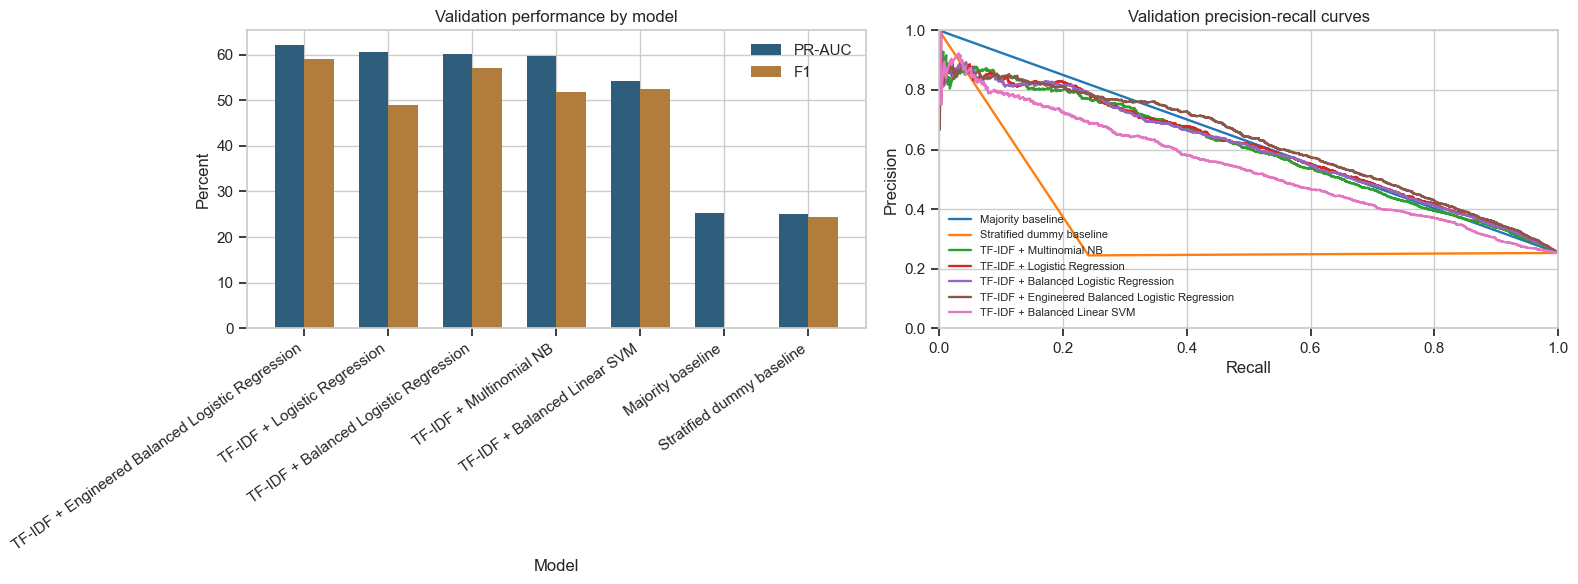

In [12]:
validation_plot = validation_results.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(validation_plot))
width = 0.35
axes[0].bar(x - width / 2, validation_plot["Average precision"] * 100, width, label="PR-AUC", color="#2f5d7c")
axes[0].bar(x + width / 2, validation_plot["F1"] * 100, width, label="F1", color="#b07d3c")
axes[0].set_title("Validation performance by model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Percent")
axes[0].set_xticks(x)
axes[0].set_xticklabels(validation_plot["Model"], rotation=35, ha="right")
axes[0].legend()

for name, fitted_info in fitted_models.items():
    estimator = fitted_info["estimator"]
    X_val = get_X(val_df, fitted_info["feature_mode"])
    scores = positive_scores(estimator, X_val)
    if scores is None:
        continue
    precision_curve, recall_curve, _ = precision_recall_curve(val_df["any_helpful"], scores)
    axes[1].plot(recall_curve, precision_curve, linewidth=1.7, label=name)

axes[1].set_title("Validation precision-recall curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## 13. Threshold Tuning for the Selected Model

The selected model produces scores, so we tune the classification threshold on the validation set to maximize positive-class F1. That tuned threshold is then applied once to the held-out test set.


In [13]:
X_val_selected = get_X(val_df, selected_feature_mode)
X_test_selected = get_X(test_df, selected_feature_mode)
val_scores = positive_scores(selected_model, X_val_selected)
test_scores = positive_scores(selected_model, X_test_selected)

if val_scores is None:
    best_threshold = 0.5
    tuned_val_predictions = selected_model.predict(X_val_selected)
    tuned_test_predictions = selected_model.predict(X_test_selected)
else:
    precision_curve, recall_curve, thresholds = precision_recall_curve(val_df["any_helpful"], val_scores)
    f1_curve = (2 * precision_curve[:-1] * recall_curve[:-1]) / np.maximum(
        precision_curve[:-1] + recall_curve[:-1],
        1e-12,
    )
    best_threshold = float(thresholds[int(np.nanargmax(f1_curve))])
    tuned_val_predictions = (val_scores >= best_threshold).astype(int)
    tuned_test_predictions = (test_scores >= best_threshold).astype(int)

tuned_rows = [
    metric_row(f"{selected_model_name} (tuned threshold)", "Validation", val_df["any_helpful"], tuned_val_predictions, val_scores),
    metric_row(f"{selected_model_name} (tuned threshold)", "Test", test_df["any_helpful"], tuned_test_predictions, test_scores),
]
tuned_results_df = pd.DataFrame(tuned_rows)
display(pd.DataFrame([{"Selected model": selected_model_name, "Tuned threshold": best_threshold}]))
display(tuned_results_df)


,Selected model,Tuned threshold
0,TF-IDF + Engineered Balanced Logistic Regression,0.5254


,Model,Split,Rows,Positive rate,Accuracy,Balanced accuracy,Precision,Recall,F1,Average precision,ROC AUC
0,TF-IDF + Engineered Balanced Logistic Regressi...,Validation,7501,0.2530,0.7656,0.7337,0.5292,0.6691,0.5910,0.6218,0.8063
1,TF-IDF + Engineered Balanced Logistic Regressi...,Test,7500,0.2531,0.7631,0.7242,0.5260,0.6454,0.5796,0.6175,0.7973


## 14. Final Confusion Matrix

The confusion matrix shows the selected model's final held-out test behavior at the validation-tuned threshold.


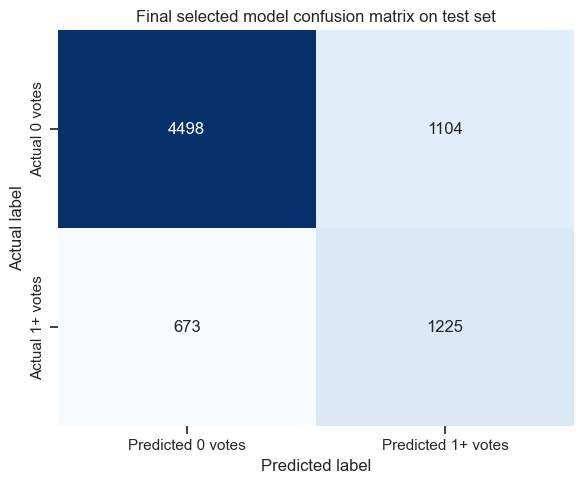

,Predicted 0 votes,Predicted 1+ votes
Actual 0 votes,4498,1104
Actual 1+ votes,673,1225


In [14]:
cm = confusion_matrix(test_df["any_helpful"], tuned_test_predictions)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0 votes", "Actual 1+ votes"],
    columns=["Predicted 0 votes", "Predicted 1+ votes"],
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Final selected model confusion matrix on test set")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
plt.tight_layout()
plt.show()

display(cm_df)


## 15. Interpreting the Selected Model

If the selected model has linear coefficients, this cell lists the TF-IDF terms most associated with the positive and negative classes. These terms are not causal explanations, but they help connect the classifier to recognizable language patterns.


In [15]:
def extract_text_coefficients(estimator) -> pd.DataFrame:
    if not hasattr(estimator, "named_steps"):
        return pd.DataFrame()
    clf = estimator.named_steps.get("clf")
    if clf is None or not hasattr(clf, "coef_"):
        return pd.DataFrame()
    if "tfidf" in estimator.named_steps:
        feature_names = estimator.named_steps["tfidf"].get_feature_names_out()
        coefficients = clf.coef_[0][: len(feature_names)]
    elif "features" in estimator.named_steps:
        tfidf_transformer = estimator.named_steps["features"].named_transformers_["tfidf"]
        feature_names = tfidf_transformer.get_feature_names_out()
        coefficients = clf.coef_[0][: len(feature_names)]
    else:
        return pd.DataFrame()
    return pd.DataFrame({"term": feature_names, "coefficient": coefficients})


coef_df = extract_text_coefficients(selected_model)
if coef_df.empty:
    top_positive_terms = pd.DataFrame({"term": ["Not available"], "coefficient": [np.nan]})
    top_negative_terms = pd.DataFrame({"term": ["Not available"], "coefficient": [np.nan]})
else:
    top_positive_terms = coef_df.sort_values("coefficient", ascending=False).head(15)
    top_negative_terms = coef_df.sort_values("coefficient", ascending=True).head(15)

display(Markdown("### Terms most associated with 1+ observed helpful votes"))
display(top_positive_terms)
display(Markdown("### Terms most associated with 0 observed helpful votes"))
display(top_negative_terms)


### Terms most associated with 1+ observed helpful votes

,term,coefficient
5218,dvd,2.1991
14549,really loved,2.0759
1543,beautiful,1.8024
5006,don waste,1.7294
600,actress,1.7158
7094,fun fun,1.6733
17622,teacher,1.6659
1369,bad acting,1.6500
9934,kind movie,1.6272
14780,release,1.5799


### Terms most associated with 0 observed helpful votes

,term,coefficient
2079,bosch,-2.2078
18242,travel,-2.0836
19775,worth watch,-1.8915
1143,ask,-1.8582
9829,keeps,-1.6820
7277,gear,-1.6287
8100,great way,-1.5769
1864,binge,-1.5745
19840,written,-1.5685
13470,pilot,-1.5235


## 16. Secondary Experiment: Exposed-Only Strong Helpfulness

The progress report used only reviews with at least one helpful vote and predicted `2+ votes` versus exactly `1 vote`. We keep that experiment as a secondary comparison, but it is no longer the main result because it ignores about three quarters of the 50K subset.


In [16]:
exposed_df = modeling_df.loc[modeling_df["helpful_vote"] >= 1].copy()
exposed_df["strong_helpful"] = (exposed_df["helpful_vote"] >= EXPOSED_STRONG_THRESHOLD).astype(int)
exposed_train, exposed_val, exposed_test = make_splits(exposed_df, "strong_helpful")

exposed_specs = [
    {
        "name": "Exposed majority baseline",
        "estimator": DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED),
        "feature_mode": "text",
    },
    {
        "name": "Exposed TF-IDF + Logistic Regression",
        "estimator": text_pipeline(LogisticRegression(max_iter=1_000, random_state=RANDOM_SEED, solver="liblinear")),
        "feature_mode": "text",
    },
    {
        "name": "Exposed TF-IDF + Balanced Linear SVM",
        "estimator": text_pipeline(LinearSVC(random_state=RANDOM_SEED, class_weight="balanced", max_iter=5_000)),
        "feature_mode": "text",
    },
]

exposed_rows = []
for spec in exposed_specs:
    _, rows = evaluate_model(
        spec["name"],
        spec["estimator"],
        spec["feature_mode"],
        exposed_train,
        {"Validation": exposed_val, "Test": exposed_test},
        "strong_helpful",
    )
    exposed_rows.extend(rows)

exposed_results_df = pd.DataFrame(exposed_rows)
exposed_summary = pd.DataFrame(
    [
        {
            "Rows": len(exposed_df),
            "Exactly 1 vote": int((exposed_df["helpful_vote"] == 1).sum()),
            "2+ votes": int((exposed_df["helpful_vote"] >= 2).sum()),
            "Positive rate": exposed_df["strong_helpful"].mean(),
        }
    ]
)
display(exposed_summary)
display(exposed_results_df.sort_values(["Split", "Average precision", "F1"], ascending=[True, False, False]))


,Rows,Exactly 1 vote,2+ votes,Positive rate
0,12654,6099,6555,0.5180


,Model,Split,Rows,Positive rate,Accuracy,Balanced accuracy,Precision,Recall,F1,Average precision,ROC AUC
3,Exposed TF-IDF + Logistic Regression,Test,1899,0.5182,0.6219,0.6208,0.6309,0.6514,0.6410,0.6972,0.6862
5,Exposed TF-IDF + Balanced Linear SVM,Test,1899,0.5182,0.5919,0.5918,0.6085,0.5955,0.6020,0.6600,0.6463
1,Exposed majority baseline,Test,1899,0.5182,0.5182,0.5000,0.5182,1.0000,0.6826,0.5182,0.5000
2,Exposed TF-IDF + Logistic Regression,Validation,1898,0.5179,0.6523,0.6498,0.6483,0.7182,0.6815,0.7208,0.7143
4,Exposed TF-IDF + Balanced Linear SVM,Validation,1898,0.5179,0.6096,0.6087,0.6208,0.6328,0.6267,0.6679,0.6567
0,Exposed majority baseline,Validation,1898,0.5179,0.5179,0.5000,0.5179,1.0000,0.6824,0.5179,0.5000


## 17. Robustness Check: Mature Review Window

To address exposure directly, this experiment restricts the data to reviews from 2014 or earlier. These reviews have had more time to accumulate helpful votes, so the zero-vote label is less likely to be caused only by recency.


In [17]:
mature_df = modeling_df.loc[modeling_df["review_year"] <= MATURE_YEAR_CUTOFF].copy()
mature_train, mature_val, mature_test = make_splits(mature_df, "any_helpful")

mature_specs = [
    {
        "name": "Mature majority baseline",
        "estimator": DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED),
        "feature_mode": "text",
    },
    {
        "name": "Mature TF-IDF + Balanced Logistic Regression",
        "estimator": text_pipeline(
            LogisticRegression(max_iter=1_000, random_state=RANDOM_SEED, solver="liblinear", class_weight="balanced")
        ),
        "feature_mode": "text",
    },
    {
        "name": "Mature TF-IDF + Engineered Balanced Logistic Regression",
        "estimator": Pipeline(
            [
                ("features", clone(engineered_preprocessor)),
                ("clf", LogisticRegression(max_iter=1_000, random_state=RANDOM_SEED, solver="liblinear", class_weight="balanced")),
            ]
        ),
        "feature_mode": "engineered",
    },
]

mature_rows = []
for spec in mature_specs:
    _, rows = evaluate_model(
        spec["name"],
        spec["estimator"],
        spec["feature_mode"],
        mature_train,
        {"Validation": mature_val, "Test": mature_test},
        "any_helpful",
    )
    mature_rows.extend(rows)

mature_results_df = pd.DataFrame(mature_rows)
mature_summary = pd.DataFrame(
    [
        {
            "Rows": len(mature_df),
            "Review years": f"{int(mature_df['review_year'].min())}-{MATURE_YEAR_CUTOFF}",
            "Positive rate": mature_df["any_helpful"].mean(),
            "Mean helpful votes": mature_df["helpful_vote"].mean(),
        }
    ]
)
display(mature_summary)
display(mature_results_df.sort_values(["Split", "Average precision", "F1"], ascending=[True, False, False]))


,Rows,Review years,Positive rate,Mean helpful votes
0,14414,1998-2014,0.3988,2.1335


,Model,Split,Rows,Positive rate,Accuracy,Balanced accuracy,Precision,Recall,F1,Average precision,ROC AUC
5,Mature TF-IDF + Engineered Balanced Logistic R...,Test,2163,0.3990,0.7453,0.7361,0.6773,0.6906,0.6839,0.7622,0.8142
3,Mature TF-IDF + Balanced Logistic Regression,Test,2163,0.3990,0.7282,0.7226,0.6486,0.6952,0.6711,0.7449,0.7991
1,Mature majority baseline,Test,2163,0.3990,0.6010,0.5000,0.0000,0.0000,0.0000,0.3990,0.5000
4,Mature TF-IDF + Engineered Balanced Logistic R...,Validation,2162,0.3987,0.7433,0.7361,0.6704,0.7007,0.6852,0.7402,0.8013
2,Mature TF-IDF + Balanced Logistic Regression,Validation,2162,0.3987,0.7155,0.7121,0.6299,0.6949,0.6608,0.7158,0.7831
0,Mature majority baseline,Validation,2162,0.3987,0.6013,0.5000,0.0000,0.0000,0.0000,0.3987,0.5000


## 18. Save Final Result Summary

This cell writes the computed results to `helpfulness_final_results_summary.json` beside the notebook. The Method and Results sections below are a preserved narrative of the original run; rerunning code updates the outputs and JSON, but does not rewrite those static Markdown sections. See the README for reproduction instructions and interpretation limits.


In [18]:
def row_to_plain_dict(row: pd.Series) -> dict:
    output = {}
    for key, value in row.items():
        if isinstance(value, (np.integer, np.floating)):
            output[key] = value.item()
        elif pd.isna(value) if isinstance(value, float) else False:
            output[key] = None
        else:
            output[key] = value
    return output


selected_default_test = results_df.loc[
    (results_df["Model"] == selected_model_name) & (results_df["Split"] == "Test")
].iloc[0]
selected_tuned_test = tuned_results_df.loc[tuned_results_df["Split"] == "Test"].iloc[0]
selected_tuned_val = tuned_results_df.loc[tuned_results_df["Split"] == "Validation"].iloc[0]

best_exposed_test = exposed_results_df.loc[exposed_results_df["Split"] == "Test"].sort_values(
    ["Average precision", "F1"], ascending=False, na_position="last"
).iloc[0]
best_mature_test = mature_results_df.loc[mature_results_df["Split"] == "Test"].sort_values(
    ["Average precision", "F1"], ascending=False, na_position="last"
).iloc[0]

report_summary = {
    "subset_rows": int(len(subset_df)),
    "modeling_rows": int(len(modeling_df)),
    "positive_rate": float(modeling_df["any_helpful"].mean()),
    "zero_vote_share": float((subset_df["helpful_vote"] == 0).mean()),
    "review_year_min": int(subset_df["review_year"].min()),
    "review_year_max": int(subset_df["review_year"].max()),
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "selected_model": selected_model_name,
    "tuned_threshold": float(best_threshold),
    "selected_default_test": row_to_plain_dict(selected_default_test),
    "selected_tuned_val": row_to_plain_dict(selected_tuned_val),
    "selected_tuned_test": row_to_plain_dict(selected_tuned_test),
    "confusion_matrix": cm.tolist(),
    "best_validation_model_table": validation_results.head(5).to_dict(orient="records"),
    "style_summary": style_summary.to_dict(orient="records"),
    "length_summary": length_summary.to_dict(orient="records"),
    "top_positive_terms": top_positive_terms.head(8).to_dict(orient="records"),
    "top_negative_terms": top_negative_terms.head(8).to_dict(orient="records"),
    "exposed_rows": int(len(exposed_df)),
    "exposed_positive_rate": float(exposed_df["strong_helpful"].mean()),
    "best_exposed_test": row_to_plain_dict(best_exposed_test),
    "mature_rows": int(len(mature_df)),
    "mature_positive_rate": float(mature_df["any_helpful"].mean()),
    "best_mature_test": row_to_plain_dict(best_mature_test),
}

REPORT_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_SUMMARY_PATH.write_text(json.dumps(report_summary, indent=2), encoding="utf-8")
print(f"Wrote final result summary to {REPORT_SUMMARY_PATH}")


Wrote final result summary to output/jupyter-notebook/helpfulness_final_results_summary.json


## Method

Our final approach treats the project as a supervised NLP classification problem over the full 50,000-review representative Movies & TV subset. The main label is `any_helpful = 1` when a review has at least one observed helpful vote and `0` otherwise. This uses the entire subset, including the zero-vote reviews that make up 74.69% of the data, while keeping the modeling assumption explicit: zero observed votes may reflect limited exposure rather than a review being objectively unhelpful. Because of that, we describe the target as *observed helpfulness* instead of absolute helpfulness.

The notebook first builds interpretable review features for analysis: review length, title length, sentence count, punctuation counts, star rating, verified-purchase status, review year, and simple lexical indicators for plot-focused and emotion-focused language. Review year is included as an exposure proxy because older reviews have had more time to receive helpful votes. We then split the 50,000 usable reviews into stratified train, validation, and test sets of 34,999, 7,501, and 7,500 reviews, preserving the 25.31% positive rate.

We compare seven methods: a majority-class dummy baseline, a stratified dummy baseline, TF-IDF with Multinomial Naive Bayes, TF-IDF with logistic regression, TF-IDF with class-weighted logistic regression, TF-IDF plus engineered features with class-weighted logistic regression, and TF-IDF with a class-weighted linear SVM. The TF-IDF models use unigram and bigram features, English stop-word removal, a minimum document frequency of 2, sublinear term frequency scaling, and a 20,000-feature cap. Since the label is imbalanced, model selection uses validation average precision (PR-AUC), with validation F1 as the tie-breaker. After selecting the best model, we tune its score threshold on the validation set to maximize F1 and apply that threshold once to the held-out test set.

Two secondary experiments check the limits of the main setup. First, we rerun the earlier exposed-only task on the 12,654 reviews with at least one helpful vote, predicting `2+ votes` versus exactly `1 vote`. Second, we run a mature-window robustness check on the 14,414 reviews from 2014 or earlier, where reviews have had more time to accumulate votes. These secondary tasks help separate the final all-subset experiment from the exposure concern raised in instructor feedback.


## Results

The full-subset experiment confirms that the zero-vote imbalance is the central difficulty: only 25.31% of the 50,000 reviews have at least one observed helpful vote. The EDA figures show that observed helpfulness is strongly related to exposure and review detail. Long reviews have a 56.59% observed-helpful rate compared with 7.49% for very short reviews. Reviews containing both plot and emotion indicators have a 46.00% observed-helpful rate, while reviews with neither indicator have a 17.72% rate. These patterns support the feature-engineering direction and connect directly to our research questions about length, specificity, and plot/emotion language.

The best validation model was **TF-IDF + Engineered Balanced Logistic Regression**. Before threshold tuning, it achieved test PR-AUC 0.617, ROC-AUC 0.797, balanced accuracy 0.723, precision 0.505, recall 0.667, and F1 0.575. After tuning the decision threshold to 0.525 on validation, the final held-out test result was accuracy 0.763, balanced accuracy 0.724, precision 0.526, recall 0.645, F1 0.580, PR-AUC 0.617, and ROC-AUC 0.797. The final confusion matrix contains 4,498 true negatives, 1,104 false positives, 673 false negatives, and 1,225 true positives.

The figures above summarize these results: the helpful-vote plots show the class imbalance, the year plot shows why exposure matters, the validation bar chart and precision-recall curves compare model quality, and the confusion-matrix heatmap shows final test behavior. The engineered logistic model wins because it combines language features with metadata and exposure-related signals instead of relying on text alone. Its most positive TF-IDF coefficients include terms such as dvd, really loved, beautiful, don waste, actress; its most negative coefficients include bosch, travel, worth watch, ask, keeps. These coefficient lists are useful for interpretation, but they should be read as model associations rather than causal explanations.

The secondary experiments give useful context. On the exposed-only task from the progress report, the best test model was **Exposed TF-IDF + Logistic Regression**, with F1 0.641 and PR-AUC 0.697. This is a cleaner balanced task, but it uses only 12,654 reviews and leaves out most of the subset. In the mature-window robustness check, the best test model was **Mature TF-IDF + Engineered Balanced Logistic Regression**, with F1 0.684 and PR-AUC 0.762 on reviews through 2014. The mature-window results are stronger than the full-subset results, which supports the instructor's point that exposure time affects the helpful-vote label. Overall, the final project successfully moves beyond the preliminary exposed-only baseline by modeling all 50,000 reviews, reporting imbalance-aware metrics, and showing that review length, plot/emotion detail, and exposure-related metadata all help predict observed helpfulness.
